# Garmin Stress vs Body Battery Trend Analysis

This notebook pulls stress and body-battery metrics from Garmin Health Snapshot exports and analyzes: 
- Daily trend behavior
- 7-day smoothed trend
- Stress-to-body-battery relationship (same-day and lagged)
- High-risk days where stress is high and body battery is low

In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
raw_path = repo_root / 'reports' / 'health_snapshots' / 'health_snapshots_raw_2026-04-11_to_2026-07-20.json'

print(f'Repository root: {repo_root}')
print(f'Using data file: {raw_path}')

Repository root: c:\Users\A717631\repo\theEagle
Using data file: c:\Users\A717631\repo\theEagle\reports\health_snapshots\health_snapshots_raw_2026-04-11_to_2026-07-20.json


In [13]:
with raw_path.open('r', encoding='utf-8') as f:
    snapshots = json.load(f)

print(f'Loaded {len(snapshots)} snapshot records')

def first_dict(value):
    if isinstance(value, list):
        for item in value:
            if isinstance(item, dict):
                return item
    return value if isinstance(value, dict) else {}

rows = []
for rec in snapshots:
    stats = rec.get('get_stats_and_body') or rec.get('get_stats') or {}
    stress_data = rec.get('get_stress_data') or rec.get('get_all_day_stress') or {}
    body_battery = first_dict(rec.get('get_body_battery'))
    body_battery_day = first_dict(rec.get('get_daily_body_battery'))

    rows.append({
        'date': rec.get('date') or stats.get('calendarDate'),
        'avg_stress_level': stats.get('averageStressLevel', stress_data.get('avgStressLevel')),
        'max_stress_level': stats.get('maxStressLevel', stress_data.get('maxStressLevel')),
        'stress_duration_sec': stats.get('stressDuration'),
        'rest_stress_duration_sec': stats.get('restStressDuration'),
        'activity_stress_duration_sec': stats.get('activityStressDuration'),
        'low_stress_duration_sec': stats.get('lowStressDuration'),
        'medium_stress_duration_sec': stats.get('mediumStressDuration'),
        'high_stress_duration_sec': stats.get('highStressDuration'),
        'stress_qualifier': stats.get('stressQualifier'),
        'bb_high': stats.get('bodyBatteryHighestValue', body_battery_day.get('bodyBatteryHighestValue')),
        'bb_low': stats.get('bodyBatteryLowestValue', body_battery_day.get('bodyBatteryLowestValue')),
        'bb_most_recent': stats.get('bodyBatteryMostRecentValue', body_battery_day.get('bodyBatteryMostRecentValue')),
        'bb_at_wake': stats.get('bodyBatteryAtWakeTime'),
        'bb_during_sleep': stats.get('bodyBatteryDuringSleep'),
        'bb_charged': stats.get('bodyBatteryChargedValue', body_battery.get('chargedValue')),
        'bb_drained': stats.get('bodyBatteryDrainedValue', body_battery.get('drainedValue')),
        'is_wellness_day': stats.get('includesWellnessData')
    })

df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

numeric_cols = [c for c in df.columns if c not in ['date', 'stress_qualifier']]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values('date').reset_index(drop=True)
df.head()

Loaded 101 snapshot records


,date,avg_stress_level,max_stress_level,stress_duration_sec,rest_stress_duration_sec,activity_stress_duration_sec,low_stress_duration_sec,medium_stress_duration_sec,high_stress_duration_sec,stress_qualifier,bb_high,bb_low,bb_most_recent,bb_at_wake,bb_during_sleep,bb_charged,bb_drained,is_wellness_day
0,2026-04-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2026-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2026-04-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2026-04-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2026-04-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [14]:
key_cols = [
    'avg_stress_level',
    'max_stress_level',
    'bb_most_recent',
    'bb_high',
    'bb_low',
    'bb_charged',
    'bb_drained'
]

quality = pd.DataFrame({
    'non_null_count': df[key_cols].notna().sum(),
    'coverage_pct': (df[key_cols].notna().mean() * 100).round(1)
}).sort_values('coverage_pct', ascending=False)

print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Rows: {len(df)}')
quality

Date range: 2026-04-11 to 2026-07-20
Rows: 101


,non_null_count,coverage_pct
avg_stress_level,86,85.1
max_stress_level,86,85.1
bb_most_recent,86,85.1
bb_high,86,85.1
bb_low,86,85.1
bb_charged,86,85.1
bb_drained,86,85.1


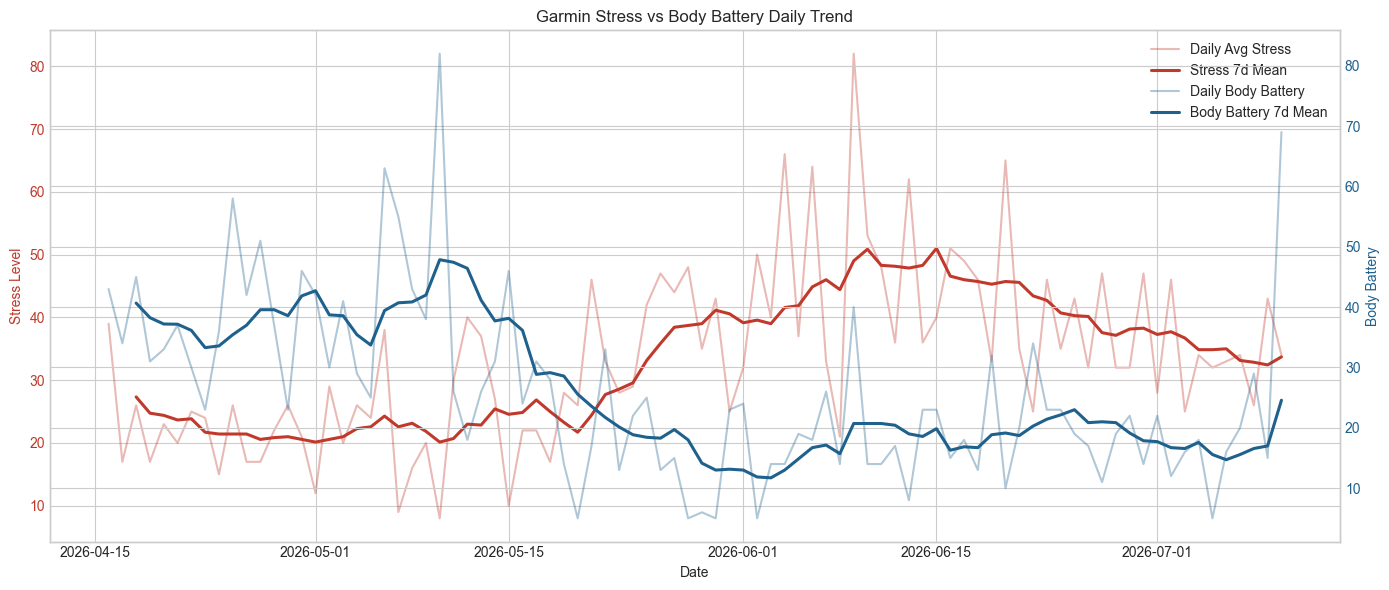

In [15]:
plot_df = df[['date', 'avg_stress_level', 'bb_most_recent']].dropna().copy()
plot_df['stress_7d'] = plot_df['avg_stress_level'].rolling(7, min_periods=3).mean()
plot_df['bb_7d'] = plot_df['bb_most_recent'].rolling(7, min_periods=3).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(plot_df['date'], plot_df['avg_stress_level'], color='#C0392B', alpha=0.35, label='Daily Avg Stress')
ax1.plot(plot_df['date'], plot_df['stress_7d'], color='#C0392B', linewidth=2.2, label='Stress 7d Mean')
ax1.set_ylabel('Stress Level', color='#C0392B')
ax1.tick_params(axis='y', labelcolor='#C0392B')

ax2.plot(plot_df['date'], plot_df['bb_most_recent'], color='#1F618D', alpha=0.35, label='Daily Body Battery')
ax2.plot(plot_df['date'], plot_df['bb_7d'], color='#1F618D', linewidth=2.2, label='Body Battery 7d Mean')
ax2.set_ylabel('Body Battery', color='#1F618D')
ax2.tick_params(axis='y', labelcolor='#1F618D')

ax1.set_title('Garmin Stress vs Body Battery Daily Trend')
ax1.set_xlabel('Date')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
plt.tight_layout()
plt.show()

,avg_stress_level,bb_most_recent,bb_next_day,stress_prev_day
avg_stress_level,1.000000,-0.516771,-0.371123,0.360472
bb_most_recent,-0.516771,1.000000,0.443729,-0.371123
bb_next_day,-0.371123,0.443729,1.000000,-0.373938
stress_prev_day,0.360472,-0.371123,-0.373938,1.000000


Same-day correlation (stress vs body battery): -0.517
Lead correlation (today stress vs next-day body battery): -0.371


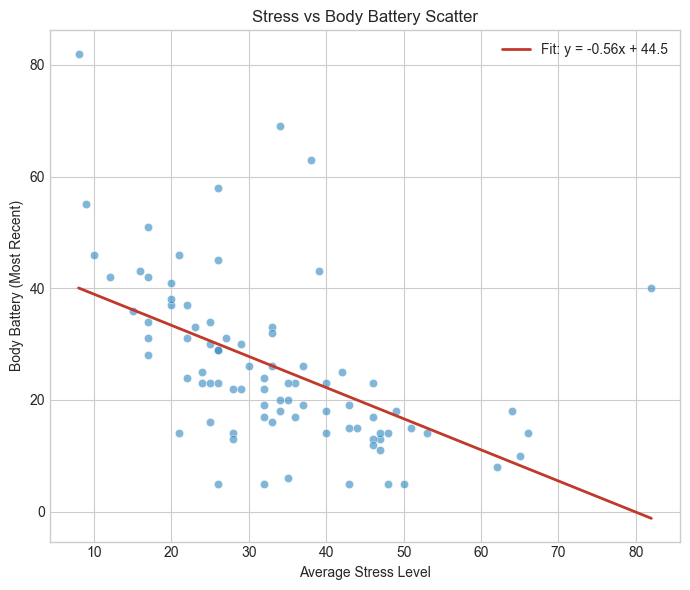

In [16]:
corr_df = df[['date', 'avg_stress_level', 'bb_most_recent']].dropna().copy()
corr_df['bb_next_day'] = corr_df['bb_most_recent'].shift(-1)
corr_df['stress_prev_day'] = corr_df['avg_stress_level'].shift(1)

corr_matrix = corr_df[['avg_stress_level', 'bb_most_recent', 'bb_next_day', 'stress_prev_day']].corr()
display(corr_matrix)

same_day_corr = corr_df['avg_stress_level'].corr(corr_df['bb_most_recent'])
next_day_corr = corr_df['avg_stress_level'].corr(corr_df['bb_next_day'])

print(f'Same-day correlation (stress vs body battery): {same_day_corr:.3f}')
print(f'Lead correlation (today stress vs next-day body battery): {next_day_corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
x = corr_df['avg_stress_level']
y = corr_df['bb_most_recent']
ax.scatter(x, y, alpha=0.6, color='#2E86C1', edgecolor='white', linewidth=0.5)

if len(corr_df) >= 3:
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, color='#C0392B', linewidth=2, label=f'Fit: y = {m:.2f}x + {b:.1f}')
    ax.legend()

ax.set_title('Stress vs Body Battery Scatter')
ax.set_xlabel('Average Stress Level')
ax.set_ylabel('Body Battery (Most Recent)')
plt.tight_layout()
plt.show()

In [17]:
analysis_df = df[['date', 'avg_stress_level', 'bb_most_recent', 'bb_low', 'bb_high']].dropna(subset=['avg_stress_level', 'bb_most_recent']).copy()

high_stress_cutoff = analysis_df['avg_stress_level'].quantile(0.8)
low_bb_cutoff = analysis_df['bb_most_recent'].quantile(0.2)

risk_days = analysis_df[(analysis_df['avg_stress_level'] >= high_stress_cutoff) & (analysis_df['bb_most_recent'] <= low_bb_cutoff)]

trend_span = analysis_df.tail(21).copy()
if len(trend_span) >= 3:
    t = np.arange(len(trend_span))
    stress_slope = np.polyfit(t, trend_span['avg_stress_level'], 1)[0]
    bb_slope = np.polyfit(t, trend_span['bb_most_recent'], 1)[0]
else:
    stress_slope = np.nan
    bb_slope = np.nan

print('Garmin Stress/Battery Analysis Summary')
print('-' * 42)
print(f'High stress threshold (80th pct): {high_stress_cutoff:.1f}')
print(f'Low body-battery threshold (20th pct): {low_bb_cutoff:.1f}')
print(f'Flagged high-stress + low-battery days: {len(risk_days)}')
print(f'21-day stress slope (units/day): {stress_slope:.3f}')
print(f'21-day body-battery slope (units/day): {bb_slope:.3f}')

if not risk_days.empty:
    display(risk_days.sort_values(['avg_stress_level', 'bb_most_recent'], ascending=[False, True]).head(15))
else:
    print('No days met the combined high-stress + low-body-battery rule.')

Garmin Stress/Battery Analysis Summary
------------------------------------------
High stress threshold (80th pct): 46.0
Low body-battery threshold (20th pct): 14.0
Flagged high-stress + low-battery days: 12
21-day stress slope (units/day): -0.539
21-day body-battery slope (units/day): 0.490


,date,avg_stress_level,bb_most_recent,bb_low,bb_high
54,2026-06-04,66.0,14.0,14.0,82.0
70,2026-06-20,65.0,10.0,10.0,86.0
63,2026-06-13,62.0,8.0,8.0,80.0
60,2026-06-10,53.0,14.0,14.0,73.0
52,2026-06-02,50.0,5.0,5.0,78.0
47,2026-05-28,48.0,5.0,5.0,80.0
61,2026-06-11,48.0,14.0,14.0,66.0
77,2026-06-27,47.0,11.0,11.0,83.0
45,2026-05-26,47.0,13.0,13.0,85.0
80,2026-06-30,47.0,14.0,14.0,84.0


Workout-type impact summary (same day and next day):


,dominant_type,days,avg_stress,avg_bb,next_day_bb_delta,next_day_stress_delta
1,interval,15,41.43,16.71,10.79,-9.86
0,easy,19,36.79,26.37,4.26,-11.21
2,strength,20,30.21,26.68,0.37,0.84


Training day vs rest day:


,group,days,avg_stress,avg_bb
0,Rest / No Training,47,29.88,29.00
1,Training Day,54,35.63,23.88


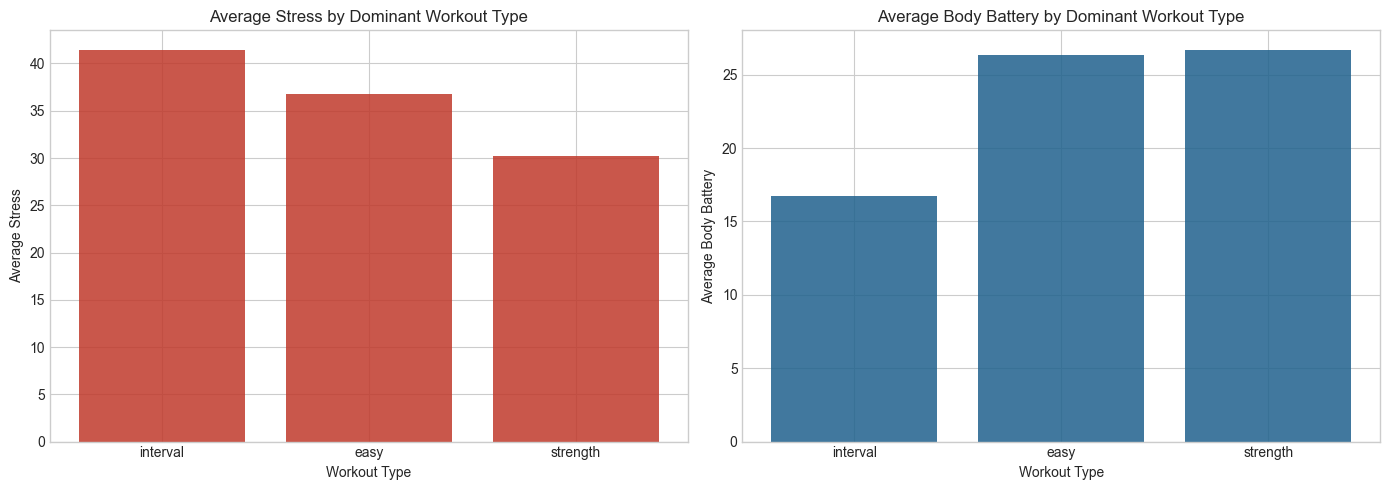

In [18]:
# Join stress/body battery with workout-type datasets (easy / interval / strength)
from pathlib import Path

reports_root = repo_root / 'reports'


def _read_training_report(path: Path, category: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['date', 'category', 'weighted_load'])

    src = pd.read_csv(path)
    if 'date' in src.columns:
        src['date'] = pd.to_datetime(src['date'], errors='coerce').dt.normalize()
    elif 'file' in src.columns:
        src['date'] = pd.to_datetime(src['file'].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})')[0], errors='coerce')
    else:
        return pd.DataFrame(columns=['date', 'category', 'weighted_load'])

    src = src.dropna(subset=['date']).copy()

    if category == 'easy':
        load = pd.to_numeric(src.get('duration_min'), errors='coerce').fillna(0)
        weight = 1.0
    elif category == 'interval':
        load = pd.to_numeric(src.get('total_workout_duration_min'), errors='coerce').fillna(0)
        weight = 1.6
    else:
        load = pd.to_numeric(src.get('duration_min'), errors='coerce').fillna(0)
        weight = 1.2

    out = pd.DataFrame({
        'date': src['date'],
        'category': category,
        'weighted_load': load * weight
    })

    return out.groupby(['date', 'category'], as_index=False)['weighted_load'].sum()


training_frames = [
    _read_training_report(reports_root / 'easy' / 'hr_improvement_analysis.csv', 'easy'),
    _read_training_report(reports_root / 'interval' / 'interval_workouts_dataset.csv', 'interval'),
    _read_training_report(reports_root / 'strength' / 'strength_endurance_sessions.csv', 'strength'),
]
training_long = pd.concat(training_frames, ignore_index=True)

if training_long.empty:
    print('No training report data found for easy/interval/strength.')
else:
    training_pivot = training_long.pivot_table(
        index='date',
        columns='category',
        values='weighted_load',
        aggfunc='sum',
        fill_value=0.0
    ).reset_index()

    for col in ['easy', 'interval', 'strength']:
        if col not in training_pivot.columns:
            training_pivot[col] = 0.0

    def _dominant_type(row: pd.Series) -> str:
        loads = {'easy': row['easy'], 'interval': row['interval'], 'strength': row['strength']}
        max_load = max(loads.values())
        if max_load <= 0:
            return 'none'
        leaders = [k for k, v in loads.items() if v == max_load]
        return '+'.join(sorted(leaders))

    training_pivot['dominant_type'] = training_pivot.apply(_dominant_type, axis=1)
    training_pivot['any_training'] = (training_pivot[['easy', 'interval', 'strength']].sum(axis=1) > 0).astype(int)

    merged = df[['date', 'avg_stress_level', 'bb_most_recent']].merge(training_pivot, on='date', how='left')
    for col in ['easy', 'interval', 'strength', 'any_training']:
        merged[col] = merged[col].fillna(0)
    merged['dominant_type'] = merged['dominant_type'].fillna('none')

    # Same-day and next-day effects by workout type.
    merged = merged.sort_values('date').reset_index(drop=True)
    merged['bb_next_day'] = merged['bb_most_recent'].shift(-1)
    merged['stress_next_day'] = merged['avg_stress_level'].shift(-1)
    merged['bb_delta_next_day'] = merged['bb_next_day'] - merged['bb_most_recent']
    merged['stress_delta_next_day'] = merged['stress_next_day'] - merged['avg_stress_level']

    summary = (
        merged[merged['dominant_type'] != 'none']
        .groupby('dominant_type', as_index=False)
        .agg(
            days=('date', 'count'),
            avg_stress=('avg_stress_level', 'mean'),
            avg_bb=('bb_most_recent', 'mean'),
            next_day_bb_delta=('bb_delta_next_day', 'mean'),
            next_day_stress_delta=('stress_delta_next_day', 'mean')
        )
        .sort_values('avg_stress', ascending=False)
    )

    overall = (
        merged.groupby('any_training', as_index=False)
        .agg(
            days=('date', 'count'),
            avg_stress=('avg_stress_level', 'mean'),
            avg_bb=('bb_most_recent', 'mean')
        )
    )
    overall['group'] = overall['any_training'].map({0: 'Rest / No Training', 1: 'Training Day'})

    print('Workout-type impact summary (same day and next day):')
    display(summary.round(2))

    print('Training day vs rest day:')
    display(overall[['group', 'days', 'avg_stress', 'avg_bb']].round(2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(summary['dominant_type'], summary['avg_stress'], color='#C0392B', alpha=0.85)
    axes[0].set_title('Average Stress by Dominant Workout Type')
    axes[0].set_ylabel('Average Stress')
    axes[0].set_xlabel('Workout Type')

    axes[1].bar(summary['dominant_type'], summary['avg_bb'], color='#1F618D', alpha=0.85)
    axes[1].set_title('Average Body Battery by Dominant Workout Type')
    axes[1].set_ylabel('Average Body Battery')
    axes[1].set_xlabel('Workout Type')

    plt.tight_layout()
    plt.show()


## Next Step Ideas

- Join this daily stress/body-battery frame with your workout metadata (intensity, duration, load).
- Build a next-day recovery classifier using stress, sleep, and training load as features.
- Add a weekly report export to markdown or CSV for longitudinal tracking.

## Implemented Next Steps\n\nThe cells below implement:\n- Workout metadata join with intensity, duration, and load\n- Next-day recovery classifier\n- Weekly longitudinal export to CSV and Markdown

In [19]:
# 1) Join daily stress/body-battery frame with workout metadata (intensity, duration, load)

from pathlib import Path


def _col_as_numeric(df_in: pd.DataFrame, col: str) -> pd.Series:
    if col in df_in.columns:
        return pd.to_numeric(df_in[col], errors='coerce')
    return pd.Series(np.nan, index=df_in.index, dtype='float64')


def _load_easy_features(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['date', 'easy_duration_min', 'easy_load', 'easy_intensity'])

    easy = pd.read_csv(path, parse_dates=['date'])
    easy['date'] = pd.to_datetime(easy['date'], errors='coerce').dt.normalize()
    easy = easy.dropna(subset=['date']).copy()

    duration = _col_as_numeric(easy, 'duration_min').fillna(0)
    intensity = _col_as_numeric(easy, 'aerobic_training_effect').fillna(0)

    load = _col_as_numeric(easy, 'exercise_load')
    fallback_load = duration * (1 + intensity)
    load = load.fillna(fallback_load)

    out = pd.DataFrame({
        'date': easy['date'],
        'easy_duration_min': duration,
        'easy_load': load,
        'easy_intensity': intensity,
        'easy_count': 1
    })
    return out.groupby('date', as_index=False).sum(numeric_only=True)


def _load_interval_features(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['date', 'interval_duration_min', 'interval_load', 'interval_intensity'])

    itv = pd.read_csv(path, parse_dates=['date'])
    itv['date'] = pd.to_datetime(itv['date'], errors='coerce').dt.normalize()
    itv = itv.dropna(subset=['date']).copy()

    duration = _col_as_numeric(itv, 'total_workout_duration_min').fillna(0)
    intensity = (
        _col_as_numeric(itv, 'aerobic_training_effect').fillna(0) +
        _col_as_numeric(itv, 'anaerobic_training_effect').fillna(0)
    )

    load = _col_as_numeric(itv, 'exercise_load')
    fallback_load = duration * (1 + intensity)
    load = load.fillna(fallback_load)

    out = pd.DataFrame({
        'date': itv['date'],
        'interval_duration_min': duration,
        'interval_load': load,
        'interval_intensity': intensity,
        'interval_count': 1
    })
    return out.groupby('date', as_index=False).sum(numeric_only=True)


def _load_strength_features(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['date', 'strength_duration_min', 'strength_load', 'strength_intensity'])

    st = pd.read_csv(path, parse_dates=['date'])
    st['date'] = pd.to_datetime(st['date'], errors='coerce').dt.normalize()
    st = st.dropna(subset=['date']).copy()

    duration = _col_as_numeric(st, 'duration_min').fillna(0)
    intensity = (
        _col_as_numeric(st, 'training_effect').fillna(0) +
        _col_as_numeric(st, 'anaerobic_training_effect').fillna(0)
    )

    load = _col_as_numeric(st, 'exercise_load')
    fallback_load = duration * (1 + intensity)
    load = load.fillna(fallback_load)

    out = pd.DataFrame({
        'date': st['date'],
        'strength_duration_min': duration,
        'strength_load': load,
        'strength_intensity': intensity,
        'strength_count': 1
    })
    return out.groupby('date', as_index=False).sum(numeric_only=True)


reports_root = repo_root / 'reports'
easy_daily = _load_easy_features(reports_root / 'easy' / 'hr_improvement_analysis.csv')
interval_daily = _load_interval_features(reports_root / 'interval' / 'interval_workouts_dataset.csv')
strength_daily = _load_strength_features(reports_root / 'strength' / 'strength_endurance_sessions.csv')

training_daily = (
    easy_daily
    .merge(interval_daily, on='date', how='outer')
    .merge(strength_daily, on='date', how='outer')
    .fillna(0)
)

training_daily['training_duration_total'] = (
    training_daily.get('easy_duration_min', 0) +
    training_daily.get('interval_duration_min', 0) +
    training_daily.get('strength_duration_min', 0)
)
training_daily['training_load_total'] = (
    training_daily.get('easy_load', 0) +
    training_daily.get('interval_load', 0) +
    training_daily.get('strength_load', 0)
)
training_daily['training_intensity_mean'] = (
    training_daily.get('easy_intensity', 0) +
    training_daily.get('interval_intensity', 0) +
    training_daily.get('strength_intensity', 0)
) / 3.0

recovery_df = df.merge(training_daily, on='date', how='left')
numeric_fill_cols = [c for c in training_daily.columns if c != 'date']
recovery_df[numeric_fill_cols] = recovery_df[numeric_fill_cols].fillna(0)

print(f'Recovery frame rows: {len(recovery_df)}')
print(f'Days with any training metadata: {(recovery_df["training_duration_total"] > 0).sum()}')

recovery_df[['date', 'avg_stress_level', 'bb_most_recent', 'bb_at_wake', 'bb_during_sleep', 'training_duration_total', 'training_load_total', 'training_intensity_mean']].tail(10)

Recovery frame rows: 101
Days with any training metadata: 54


,date,avg_stress_level,bb_most_recent,bb_at_wake,bb_during_sleep,training_duration_total,training_load_total,training_intensity_mean
91,2026-07-11,NaN,NaN,NaN,NaN,121.5,704.7,1.6
92,2026-07-12,NaN,NaN,NaN,NaN,0.0,0.0,0.0
93,2026-07-13,NaN,NaN,NaN,NaN,0.0,0.0,0.0
94,2026-07-14,NaN,NaN,NaN,NaN,0.0,0.0,0.0
95,2026-07-15,NaN,NaN,NaN,NaN,0.0,0.0,0.0
96,2026-07-16,NaN,NaN,NaN,NaN,0.0,0.0,0.0
97,2026-07-17,NaN,NaN,NaN,NaN,0.0,0.0,0.0
98,2026-07-18,NaN,NaN,NaN,NaN,0.0,0.0,0.0
99,2026-07-19,NaN,NaN,NaN,NaN,0.0,0.0,0.0
100,2026-07-20,NaN,NaN,NaN,NaN,0.0,0.0,0.0


In [20]:
# 2) Build a next-day recovery classifier using stress, sleep, and training-load features

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split


clf_df = recovery_df.copy().sort_values('date').reset_index(drop=True)
clf_df['bb_next_day'] = clf_df['bb_most_recent'].shift(-1)
clf_df['stress_next_day'] = clf_df['avg_stress_level'].shift(-1)
clf_df['bb_delta_next_day'] = clf_df['bb_next_day'] - clf_df['bb_most_recent']
clf_df['stress_delta_next_day'] = clf_df['stress_next_day'] - clf_df['avg_stress_level']

# Recovery target: body battery up and stress down the next day.
clf_df['recovered_next_day'] = ((clf_df['bb_delta_next_day'] > 0) & (clf_df['stress_delta_next_day'] < 0)).astype(float)

feature_cols = [
    'avg_stress_level', 'max_stress_level',
    'bb_most_recent', 'bb_low', 'bb_high', 'bb_at_wake', 'bb_during_sleep',
    'training_duration_total', 'training_load_total', 'training_intensity_mean',
    'easy_count', 'interval_count', 'strength_count'
]

usable = clf_df.dropna(subset=['recovered_next_day']).copy()
X = usable[feature_cols]
y = usable['recovered_next_day'].astype(int)

valid_rows = X.notna().any(axis=1)
X = X[valid_rows]
y = y[valid_rows]

if len(X) < 20 or y.nunique() < 2:
    print('Not enough labeled rows or class diversity to train a stable classifier.')
else:
    stratify_arg = y if y.nunique() > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=stratify_arg
    )

    imputer = SimpleImputer(strategy='median')
    X_train_i = imputer.fit_transform(X_train)
    X_test_i = imputer.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=2
    )
    model.fit(X_train_i, y_train)

    pred = model.predict(X_test_i)
    pred_prob = model.predict_proba(X_test_i)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, pred_prob) if len(set(y_test)) > 1 else np.nan

    print('Recovery classifier metrics')
    print('-' * 28)
    print(f'Rows used: {len(X)}')
    print(f'Positive class rate: {y.mean():.3f}')
    print(f'Accuracy: {acc:.3f}')
    print(f'ROC AUC: {auc:.3f}')
    print('\nClassification report:')
    print(classification_report(y_test, pred, digits=3))

    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    display(feature_importance)


Recovery classifier metrics
----------------------------
Rows used: 101
Positive class rate: 0.257
Accuracy: 0.808
ROC AUC: 0.857

Classification report:
              precision    recall  f1-score   support

           0      0.889     0.842     0.865        19
           1      0.625     0.714     0.667         7

    accuracy                          0.808        26
   macro avg      0.757     0.778     0.766        26
weighted avg      0.818     0.808     0.812        26



,feature,importance
8,training_load_total,0.183975
9,training_intensity_mean,0.168883
7,training_duration_total,0.122014
0,avg_stress_level,0.112179
4,bb_high,0.092911
2,bb_most_recent,0.086954
3,bb_low,0.079316
1,max_stress_level,0.072075
10,easy_count,0.050325
11,interval_count,0.011801


In [21]:
# 3) Weekly longitudinal report export to CSV and Markdown

export_df = recovery_df.copy().sort_values('date').reset_index(drop=True)
export_df['bb_next_day'] = export_df['bb_most_recent'].shift(-1)
export_df['stress_next_day'] = export_df['avg_stress_level'].shift(-1)
export_df['recovered_next_day'] = (
    (export_df['bb_next_day'] - export_df['bb_most_recent'] > 0) &
    (export_df['stress_next_day'] - export_df['avg_stress_level'] < 0)
).astype(float)

export_df['week_start'] = export_df['date'] - pd.to_timedelta(export_df['date'].dt.weekday, unit='D')

weekly_report = (
    export_df.groupby('week_start', as_index=False)
    .agg(
        days=('date', 'count'),
        avg_stress=('avg_stress_level', 'mean'),
        avg_body_battery=('bb_most_recent', 'mean'),
        avg_bb_at_wake=('bb_at_wake', 'mean'),
        avg_bb_during_sleep=('bb_during_sleep', 'mean'),
        total_training_duration_min=('training_duration_total', 'sum'),
        avg_training_load=('training_load_total', 'mean'),
        avg_training_intensity=('training_intensity_mean', 'mean'),
        recovery_rate_next_day=('recovered_next_day', 'mean')
    )
    .sort_values('week_start')
)

weekly_report['recovery_rate_next_day_pct'] = (weekly_report['recovery_rate_next_day'] * 100).round(1)

export_dir = repo_root / 'reports' / 'health_snapshots'
export_dir.mkdir(parents=True, exist_ok=True)

csv_path = export_dir / 'weekly_stress_body_battery_report.csv'
md_path = export_dir / 'weekly_stress_body_battery_report.md'

weekly_report.to_csv(csv_path, index=False)


def _to_markdown_table(df_in: pd.DataFrame) -> str:
    tmp = df_in.copy()
    for c in tmp.columns:
        if np.issubdtype(tmp[c].dtype, np.number):
            tmp[c] = tmp[c].round(2)
    tmp = tmp.fillna('')

    headers = [str(c) for c in tmp.columns]
    header_row = '| ' + ' | '.join(headers) + ' |'
    sep_row = '| ' + ' | '.join(['---'] * len(headers)) + ' |'

    data_rows = []
    for _, r in tmp.iterrows():
        data_rows.append('| ' + ' | '.join(str(r[c]) for c in tmp.columns) + ' |')

    return '\n'.join([header_row, sep_row] + data_rows)


last_12 = weekly_report.tail(12).copy()
md_table = _to_markdown_table(last_12)
md_text = (
    '# Weekly Stress vs Body Battery Longitudinal Report\n\n'
    f'- Generated: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}\n'
    f'- Source: {raw_path.name}\n'
    f'- Weeks in report: {len(weekly_report)}\n\n'
    '## Last 12 Weeks\n\n' +
    md_table + '\n'
)
md_path.write_text(md_text, encoding='utf-8')

print(f'Weekly CSV exported to: {csv_path}')
print(f'Weekly Markdown exported to: {md_path}')

display(weekly_report.tail(8).round(2))

Weekly CSV exported to: c:\Users\A717631\repo\theEagle\reports\health_snapshots\weekly_stress_body_battery_report.csv
Weekly Markdown exported to: c:\Users\A717631\repo\theEagle\reports\health_snapshots\weekly_stress_body_battery_report.md


,week_start,days,avg_stress,avg_body_battery,avg_bb_at_wake,avg_bb_during_sleep,total_training_duration_min,avg_training_load,avg_training_intensity,recovery_rate_next_day,recovery_rate_next_day_pct
8,2026-06-01,7,46.00,17.14,NaN,NaN,425.1,263.15,0.75,0.43,42.9
9,2026-06-08,7,48.29,18.57,87.0,72.0,170.3,95.59,0.28,0.29,28.6
10,2026-06-15,7,45.57,18.71,NaN,NaN,450.1,270.10,0.76,0.57,57.1
11,2026-06-22,7,37.14,20.86,NaN,NaN,411.8,269.67,0.84,0.14,14.3
12,2026-06-29,7,34.86,15.57,NaN,NaN,383.5,222.50,0.59,0.29,28.6
13,2026-07-06,7,34.00,29.80,NaN,NaN,491.8,278.82,0.70,0.29,28.6
14,2026-07-13,7,NaN,NaN,NaN,NaN,0.0,0.00,0.00,0.00,0.0
15,2026-07-20,1,NaN,NaN,NaN,NaN,0.0,0.00,0.00,0.00,0.0


## Stress Reason Analysis\n\nThis section infers likely stress drivers per day using Garmin stress metrics, recovery status, and training context.

Likely stress drivers summary:


,likely_stress_reason,days,mean_stress,mean_body_battery,mean_training_load
1,Low baseline stress,51,24.37,31.18,156.74
3,Training load driven,16,49.25,13.88,469.21
2,Mixed or unclear driver,14,47.07,21.93,95.20
0,Balanced or controlled stress,5,35.80,21.80,184.67


Top high-stress days with inferred reason:


,date,avg_stress_level,bb_most_recent,training_duration_total,training_load_total,stress_qualifier,likely_stress_reason
59,2026-06-09,82.0,40.0,0.0,0.00,UNKNOWN,Mixed or unclear driver
54,2026-06-04,66.0,14.0,90.0,387.00,UNKNOWN,Training load driven
70,2026-06-20,65.0,10.0,88.5,522.15,VERY_STRESSFUL_AWAKE,Training load driven
56,2026-06-06,64.0,18.0,103.0,659.20,UNKNOWN,Training load driven
63,2026-06-13,62.0,8.0,73.3,300.53,VERY_STRESSFUL_AWAKE,Mixed or unclear driver
60,2026-06-10,53.0,14.0,0.0,0.00,UNKNOWN,Mixed or unclear driver
66,2026-06-16,51.0,15.0,90.1,387.43,UNKNOWN,Training load driven
52,2026-06-02,50.0,5.0,75.1,307.91,STRESSFUL_AWAKE,Mixed or unclear driver
67,2026-06-17,49.0,18.0,66.9,160.56,UNKNOWN,Mixed or unclear driver
47,2026-05-28,48.0,5.0,90.1,387.43,STRESSFUL_AWAKE,Training load driven


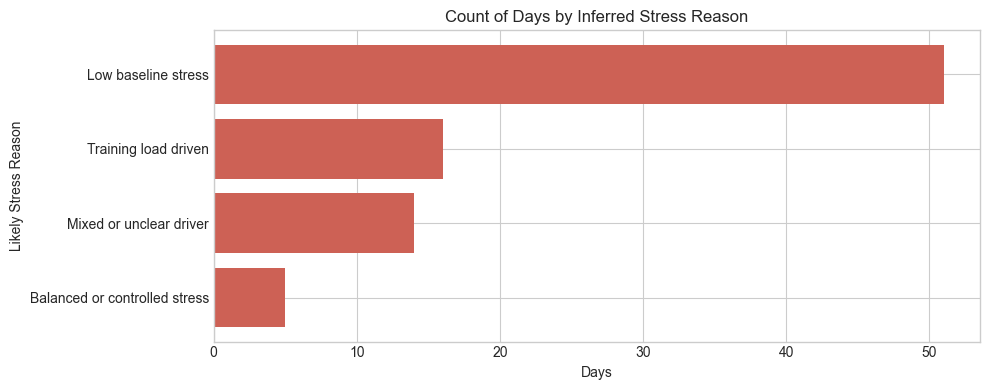

In [22]:
# Infer likely stress reason per day

reason_df = recovery_df.copy().sort_values('date').reset_index(drop=True)

total_stress = reason_df['stress_duration_sec'].replace(0, np.nan)
reason_df['rest_ratio'] = reason_df['rest_stress_duration_sec'] / total_stress
reason_df['high_stress_ratio'] = reason_df['high_stress_duration_sec'] / total_stress
reason_df['sleep_recovery_low'] = (
    reason_df['bb_at_wake'].fillna(999) <= 45
) | (
    reason_df['bb_during_sleep'].fillna(999) <= 40
)
reason_df['training_day'] = reason_df['training_duration_total'].fillna(0) > 0


def classify_stress_reason(row: pd.Series) -> str:
    avg_stress = row.get('avg_stress_level')
    if pd.isna(avg_stress):
        return 'No stress data'

    high_stress = avg_stress >= 35
    very_high_stress = avg_stress >= 45

    interval_or_hard = row.get('interval_count', 0) > 0 or row.get('interval_duration_min', 0) >= 45
    high_training_load = row.get('training_load_total', 0) >= reason_df['training_load_total'].quantile(0.75)

    rest_ratio = row.get('rest_ratio')
    high_rest_stress = pd.notna(rest_ratio) and rest_ratio >= 0.55

    poor_recovery = bool(row.get('sleep_recovery_low', False))
    qualifier = str(row.get('stress_qualifier') or '').upper()

    if not high_stress:
        return 'Low baseline stress'

    if (interval_or_hard or high_training_load) and not high_rest_stress:
        return 'Training load driven'

    if poor_recovery and high_rest_stress:
        return 'Poor recovery or sleep strain'

    if 'BALANCED' in qualifier or 'CALM' in qualifier:
        return 'Balanced or controlled stress'

    if very_high_stress and high_rest_stress:
        return 'Non-training life stress likely'

    if high_training_load:
        return 'Mixed load and recovery strain'

    return 'Mixed or unclear driver'


reason_df['likely_stress_reason'] = reason_df.apply(classify_stress_reason, axis=1)

reason_summary = (
    reason_df[reason_df['avg_stress_level'].notna()]
    .groupby('likely_stress_reason', as_index=False)
    .agg(
        days=('date', 'count'),
        mean_stress=('avg_stress_level', 'mean'),
        mean_body_battery=('bb_most_recent', 'mean'),
        mean_training_load=('training_load_total', 'mean')
    )
    .sort_values(['days', 'mean_stress'], ascending=[False, False])
)

print('Likely stress drivers summary:')
display(reason_summary.round(2))

high_days = reason_df[reason_df['avg_stress_level'] >= 40].copy()
high_days = high_days[
    ['date', 'avg_stress_level', 'bb_most_recent', 'training_duration_total', 'training_load_total', 'stress_qualifier', 'likely_stress_reason']
].sort_values('avg_stress_level', ascending=False)

print('Top high-stress days with inferred reason:')
display(high_days.head(20))

fig, ax = plt.subplots(figsize=(10, 4))
plot_data = reason_summary.sort_values('days', ascending=True)
ax.barh(plot_data['likely_stress_reason'], plot_data['days'], color='#CD6155')
ax.set_title('Count of Days by Inferred Stress Reason')
ax.set_xlabel('Days')
ax.set_ylabel('Likely Stress Reason')
plt.tight_layout()
plt.show()